## 1. Import Library

In [1]:
import sys
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
from IPython.display import display

Tahap pertama yang kita lakukan adalah memanggil semua *library* pendukung yang dibutuhkan dalam proses pengolahan citra dan klasifikasi. Di sini kita menggunakan `cv2` (OpenCV) dan `skimage` untuk mengolah gambar dan mengekstrak fitur teksturnya. Untuk perhitungan matriks, kita memakai `numpy`, sedangkan `pandas` akan kita gunakan untuk menyusun hasil ekstraksi menjadi tabel data yang rapi. Selain itu, kita juga mengimpor algoritma *Machine Learning* seperti Random Forest, SVM, dan KNN dari `scikit-learn` beserta alat ukur akurasinya. Terakhir, `matplotlib` dan `seaborn` disiapkan untuk menampilkan visualisasi grafik.

## 2. Load Dataset

Langkah selanjutnya adalah memuat gambar dataset ke dalam memori program. Kode di bawah ini akan membuka folder `dataset` dan membaca setiap sub-folder di dalamnya. Nama dari sub-folder tersebut otomatis dijadikan sebagai label kelas (misalnya, daun dengan *Black Rot* atau daun sehat). Setiap gambar yang berhasil dibaca akan disimpan dalam *array* `data`, dan labelnya disimpan dalam *array* `labels`. Jika ada gambar yang rusak, sistem akan otomatis melewatinya. Output di bawah ini akan menampilkan total gambar yang berhasil dimuat beserta daftar kelas yang ditemukan, untuk memastikan semua data sudah masuk dengan benar.

In [2]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("dataset"):
    sub_folder_path = os.path.join("dataset", sub_folder)
    if os.path.isdir(sub_folder_path):
        for i, filename in enumerate(os.listdir(sub_folder_path)):
            img_path = os.path.join(sub_folder_path, filename)
            img = cv.imread(img_path)

            if img is None:
                continue

            data.append(img)
            labels.append(sub_folder)
            file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total gambar yang dimuat: {len(data)}")
print(f"Daftar kelas yang ditemukan: {sorted(set(labels))}")

Total gambar yang dimuat: 200
Daftar kelas yang ditemukan: ['Grape_black_rot_100', 'daun_sehat_100']


## 3. Definisi Pipeline Preprocessing

In [3]:
TARGET_SIZE = (256, 256)

def gray(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray_img = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray_img = resized
    return gray_img.astype(np.uint8)

def median(image_input, kernel_size=5):
    img = image_input.copy()
    pad_size = kernel_size // 2
    padded = np.pad(img, pad_size, mode='constant')
    height, width = img.shape
    K = kernel_size * kernel_size

    windows = np.zeros((K, height, width), dtype=np.uint8)
    idx = 0
    for di in range(kernel_size):
        for dj in range(kernel_size):
            windows[idx] = padded[di:di+height, dj:dj+width]
            idx += 1

    half = (K + 1) // 2
    cum_count = np.zeros((height, width), dtype=np.int32)
    median_result = np.zeros((height, width), dtype=np.uint8)
    selesai = np.zeros((height, width), dtype=bool)

    for v in range(256):
        count_v = np.sum(windows == v, axis=0)
        cum_count = cum_count + count_v
        baru_capai = (cum_count >= half) & (~selesai)
        median_result[baru_capai] = v
        selesai = selesai | baru_capai

    return median_result.astype(np.uint8)

def histogram_equalization(image_input):
    img = image_input.copy()
    L = 256
    counts, _ = np.histogram(img, bins=L, range=(0, L))
    cdf = np.cumsum(counts)

    cdf_min = np.min(cdf[cdf > 0])
    total_pixel = np.sum(counts)

    mapping = np.round((cdf - cdf_min) / (total_pixel - cdf_min) * (L - 1))
    mapping = np.clip(mapping, 0, L - 1)
    return mapping[img].astype(np.uint8)

def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i,j] = np.sum(region * kernel)
    return canvas

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    max_val = np.max(canvas)
    if max_val > 0:
        canvas = canvas * 255.0 / max_val
    return np.clip(canvas, 0, 255).astype(np.uint8)

sobelX = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobelY = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)
robertsX = np.array([[1, 0], [0, -1]], dtype=np.float32)
robertsY = np.array([[0, 1], [-1, 0]], dtype=np.float32)

def prepro(image):
    img1 = gray(image)
    img2 = median(img1)
    img3 = histogram_equalization(img2)
    img4 = edge(img3, sobelX, sobelY)
    img5 = edge(img4, robertsX, robertsY)
    return img1, img2, img3, img4, img5

def run_prepro(image):
    _, _, _, _, final_img = prepro(image)
    return final_img

Pada percobaan sebelumnya (*pre 1*), kita hanya mengandalkan perataan kontras. Mengingat pada *pre 1* kita tidak secara eksplisit menegaskan batas-batas objek, kali ini di tahap *pre 2* kita menyisipkan tambahan berupa teknik deteksi tepi (*edge detection*). Tujuannya sederhana: kita ingin melihat apakah pola tulang daun dan bercak infeksi penyakit bisa ditangkap lebih tajam oleh model dengan bantuan modifikasi garis tepi.

Pada blok kode di atas, kita merangkai beberapa tahap secara berurutan:
1. `gray`: Mengubah ukuran gambar menjadi standar 256x256 piksel dan membuang warnanya (*Grayscale*).
2. `median`: Menggunakan *Median Filter* untuk menghaluskan *noise*.
3. `histogram_equalization`: Meratakan kontras gambar.
4. **`convolution` dan `edge` (Pembaruan dari pre 1)**: Menggunakan operator *Sobel* dan *Roberts* untuk mendeteksi tepi gambar, sehingga tekstur garis daun menjadi sangat terlihat menonjol.

## 4. Visualisasi Hasil Preprocessing

Untuk melihat langsung bagaimana fungsi *preprocessing* ini bekerja dan bedanya dengan *pre 1*, kode di bawah akan mengambil sampel gambar acak dari setiap kelas.

Saat *output* dijalankan, kumpulan gambar yang membuktikan penambahan metode operator *Sobel* dan *Roberts* ini akan terlihat jelas. Garis batas (*edges*) dari setiap bentuk daun maupun spot bercak infeksi tiba-tiba menyala tajam dan berubah menjadi kontras garis putih yang tegas, berbeda dengan hasil *pre 1* yang hanya mempertahankan bentuk citra daun biasa yang dikontraskan.

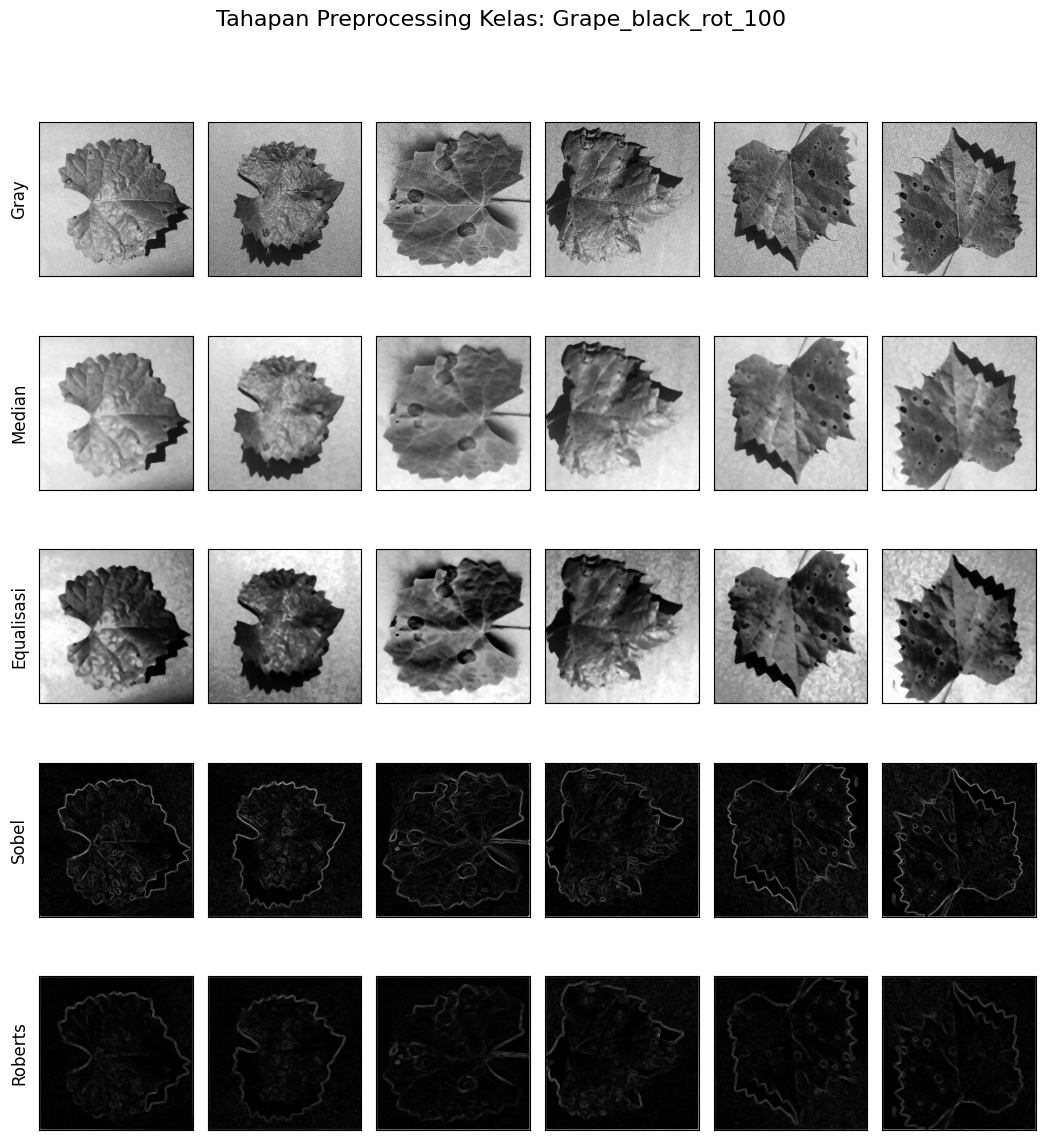

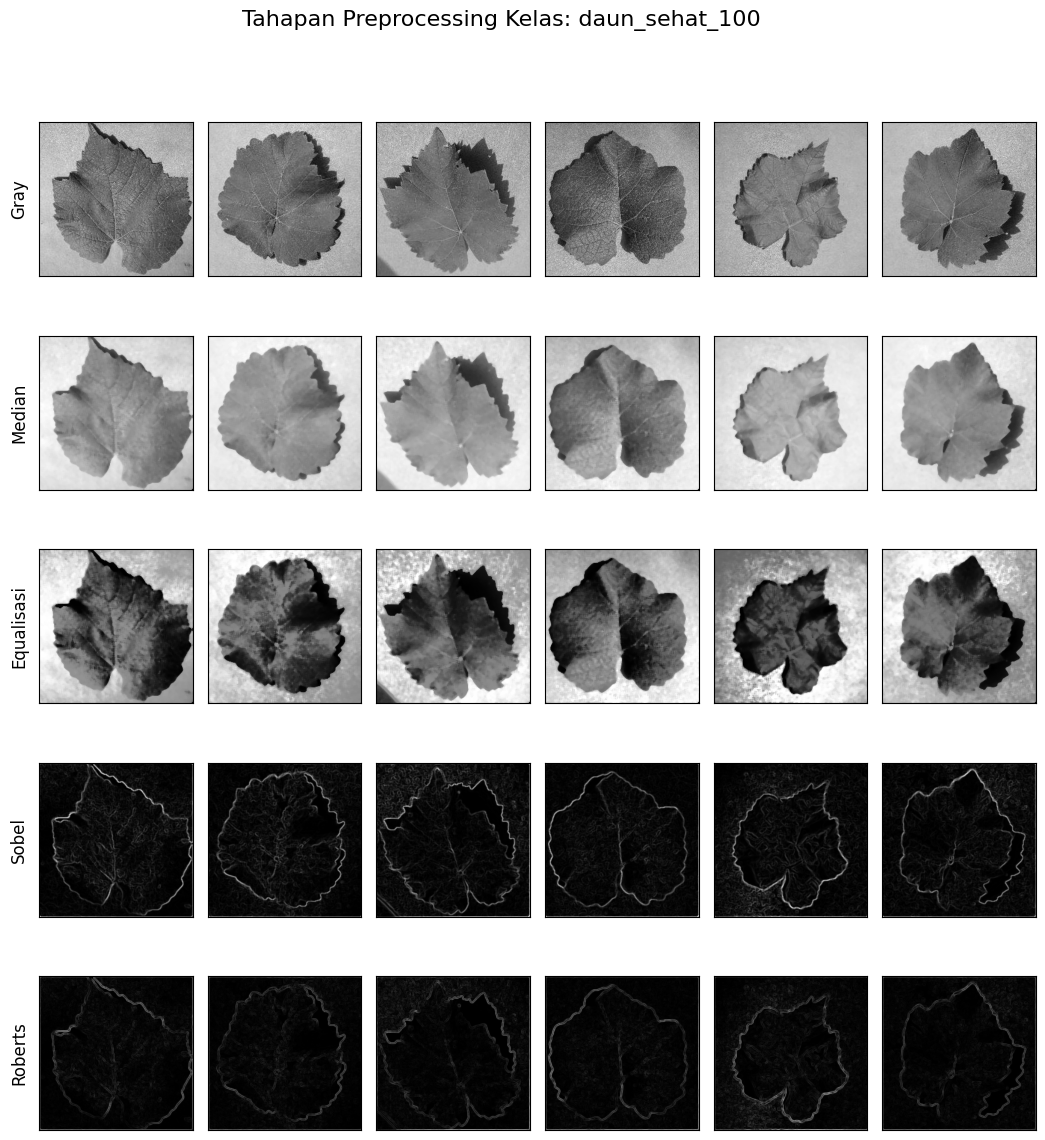

In [4]:
dataPreprocessed = [run_prepro(img) for img in data]
unique_labels = sorted(set(labels))
nama_step = ['Gray', 'Median', 'Equalisasi', 'Sobel', 'Roberts']

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    n_sample = min(6, len(idxs))

    fig, axs = plt.subplots(5, 6, figsize=(11, 12))
    fig.suptitle(f'Tahapan Preprocessing Kelas: {label}', fontsize=16)

    for k in range(n_sample):
        img_asli = data[idxs[k]]
        hasil_tahap = prepro(img_asli)
        
        for row in range(5):
            axs[row][k].imshow(hasil_tahap[row], cmap='gray')
            axs[row][k].set_xticks([])
            axs[row][k].set_yticks([])
            if k == 0:
                axs[row][k].set_ylabel(nama_step[row], fontsize=12, labelpad=8)

    for k in range(n_sample, 6):
        for row in range(5):
            axs[row][k].axis('off')

    plt.tight_layout(rect=[0.04, 0, 1, 1])
    plt.subplots_adjust(top=0.92)
    plt.show()

## 5. Definisi Fungsi Feature Extraction GLCM

In [5]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Angle harus 0, 45, 90, atau 135.")
    
    matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Setelah proses garis tepi (*Sobel-Roberts*) selesai, citra ditarik nilai teksturnya menggunakan pendekatan *Gray-Level Co-occurrence Matrix* (GLCM).

Sama seperti alur algoritma *pre 1*, kita menerapkan 7 modul pembaca tekstur: `Correlation` (mengukur keteraturan garis tekstur yang kini sudah dipertebal oleh operator deteksi tepi), `Contrast` dan `Dissimilarity` (menangkap kekasaran tepi garis), `Homogeneity` (mengukur tingkat kehalusan antar tepi), `ASM` dan `Energy`, dan terakhir `Entropy` (mengukur keacakan pola tebaran garis patah-patah dari kerusakan patologis).

## 6. Komputasi Matriks Probabilitas Multi-Sudut

In [6]:
Derajat0, Derajat45, Derajat90, Derajat135 = [], [], [], []

for img in dataPreprocessed:
    Derajat0.append(glcm(img, 0))
    Derajat45.append(glcm(img, 45))
    Derajat90.append(glcm(img, 90))
    Derajat135.append(glcm(img, 135))

Mengingat guratan garis tepi seringkali menyilang dan tak beraturan posisinya, perhitungan sudut GLCM 4 arah mutlak dilanjutkan. Baris kode komputasi di atas mencatat secara simultan pada bukaan rotasi 0, 45, 90, dan 135 derajat agar informasi matriks spasial yang tertangkap bisa proporsional dan tidak buta sudut.

## 7. Inisialisasi Array Feature Extraction

In [7]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

Sebagai persiapan sebelum ekstraksi dilakukan secara beruntun, 28 tabung kontainer *array* dideklarasikan. Tujuannya hanya satu: menjaga seluruh irisan *cross-section* fungsi nilai fitur dan arah sudut matriks tetap terdokumentasi akurat di jalurnya masing-masing.

## 8. Feature Extraction: Correlation

In [8]:
for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

Penggalian statistik yang pertama memproses fitur `Correlation`. Pola garis siluet tepi dari daun di *pre 2* ini ditaksir keseimbangan strukturnya, dengan spesimen sehat selalu mendominasi persentase linearitas piksel yang lurus dan kokoh ketimbang sampel yang meradang rusak.

## 9. Feature Extraction: Contrast

In [9]:
for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

Ekskavasi berikutnya merambah dimensi nilai `Contrast`. Penajaman batas (*edges*) akan berdampak signfikan pada skor nilai kekontrasan di sini. Setiap lesi kecil dari spora akan terekspos menjadi jurang intensitas perbedaan warna yang radikal, yang amat membantu memisahkan klasifikasinya.

## 10. Feature Extraction: Dissimilarity

In [10]:
for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

Ketidaksamaan derajat linier dipertimbangkan lewat ekstraksi `Dissimilarity`. Dengan skala pembacaan yang lebih landai dari `Contrast`, ia bisa mendeteksi perubahan mikro-spasial di sekitar kerangka objek yang membedakan tepi kasar infeksi sekunder dan sisi halus pertumbuhan alami.

## 11. Feature Extraction: Homogeneity

In [11]:
for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

Menginjak ke parameter `Homogeneity`, indeks yang menaksir kemulusan tekstur dikerahkan. Meski sudah dikenakan metode deteksi tepi siluet, daun spesimen yang sehat tidak kehilangan homogenitas rata-ratanya karena tepian alaminya membentang secara harmonis.

## 12. Feature Extraction: Entropy

In [12]:
for i in range(len(dataPreprocessed)):  
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

Melalui iterasi nilai `Entropy`, kadar distorsi sebaran rintik dianalisis. Garis tepi (*edges*) dari sel tumbuhan berpenyakit cenderung robek dan patah, sehingga menyebabkan tingkat keacakan geometri (*entropy*) memuncak dibanding sampel bersih.

## 13. Feature Extraction: ASM

In [13]:
for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

Parameter yang membuntuti nilai entropi adalah evaluasi keajegan citra, `Angular Second Moment` (ASM). Kemunculan blok matriks seragam yang mendominasi lembaran dihitung untuk membantu meyakinkan mesin sejauh mana kelayakan konsistensi data yang sedang diuji.

## 14. Feature Extraction: Energy

In [14]:
for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

Analisis akhir GLCM rampung tatkala indikator parameter `Energy` mereduksi rasio komputasional angka ASM ke dimensi akar desimal yang lebih ramah kalkulasi.

## 15. Pembentukan DataFrame

Keseluruhan 28 elemen nilai tekstur spasial dari garis-garis siluet *Sobel* dan *Roberts* belum siap diproses algoritma jika hanya bertumpuk sembarangan.

Pustaka fungsional `pandas DataFrame` menyelesaikan konflik ini dengan menyuntikkan keteraturan matriks. Tiap barisan hasil turunan fitur ditautkan selaras dengan identitas file asalnya. Tabel pratinjau yang tercetak persis di bawah membuktikan perwajahan *dataset* awal yang sudah terbentuk tertib secara empiris.

In [15]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
display(df.head())

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,daun_sehat_100_1.jpg,daun_sehat_100,278.846829,432.734856,230.441559,449.381915,0.306728,0.273539,0.311337,0.267850,...,0.008283,0.007033,0.089874,0.084924,0.091012,0.083861,0.742212,0.549513,0.797691,0.532442
1,daun_sehat_100_2.jpg,daun_sehat_100,226.446186,369.217470,194.844133,367.839554,0.318421,0.276682,0.317150,0.278522,...,0.008576,0.007519,0.092980,0.086487,0.092607,0.086714,0.771528,0.566771,0.803647,0.568610
2,daun_sehat_100_3.jpg,daun_sehat_100,273.399326,498.372810,295.653324,508.011042,0.295383,0.260280,0.295495,0.256506,...,0.007369,0.006333,0.085535,0.080157,0.085841,0.079578,0.766101,0.487256,0.744854,0.477403
3,daun_sehat_100_4.jpg,daun_sehat_100,274.786918,451.166767,229.075904,438.726705,0.300271,0.258098,0.300260,0.259251,...,0.008827,0.007782,0.093722,0.087996,0.093954,0.088215,0.729219,0.477272,0.780634,0.491926
4,daun_sehat_100_5.jpg,daun_sehat_100,306.702574,502.239477,268.074280,478.934364,0.247483,0.210000,0.244896,0.211025,...,0.005007,0.004399,0.070961,0.066089,0.070763,0.066327,0.707597,0.448677,0.750044,0.474392


## 16. Feature Selection dengan Threshold Korelasi

Sama seperti pada `pre 1`, dimensi variabel observasi yang terlampau membludak rentan menjebak akurasi pengenalan prediksi (*overfitting*) bila menyimpan duplikasi parameter korelasi kembar.

Mengandalkan limit koefisien 0.95, algoritma blok ini mengeksekusi buang seluruh kembaran redundan tersebut, sehingga memangkas rasio variabel jadi sangat efektif. *Output Heatmap Correlation* berkotak-kotak biru di bawahnya akan mengonfirmasi bahwa amunisi fitur penentu yang terselamatkan sudah benar-benar kebal dari deviasi kolinearitas, alias independen.

Dimensi fitur inisial (Pre-selection) : 28
Dimensi fitur akhir (Post-selection) : 6
Kumpulan variabel fitur fungsional terpilih: ['Contrast0', 'Homogeneity0', 'Dissimilarity0', 'Correlation0', 'Correlation45', 'Correlation90']


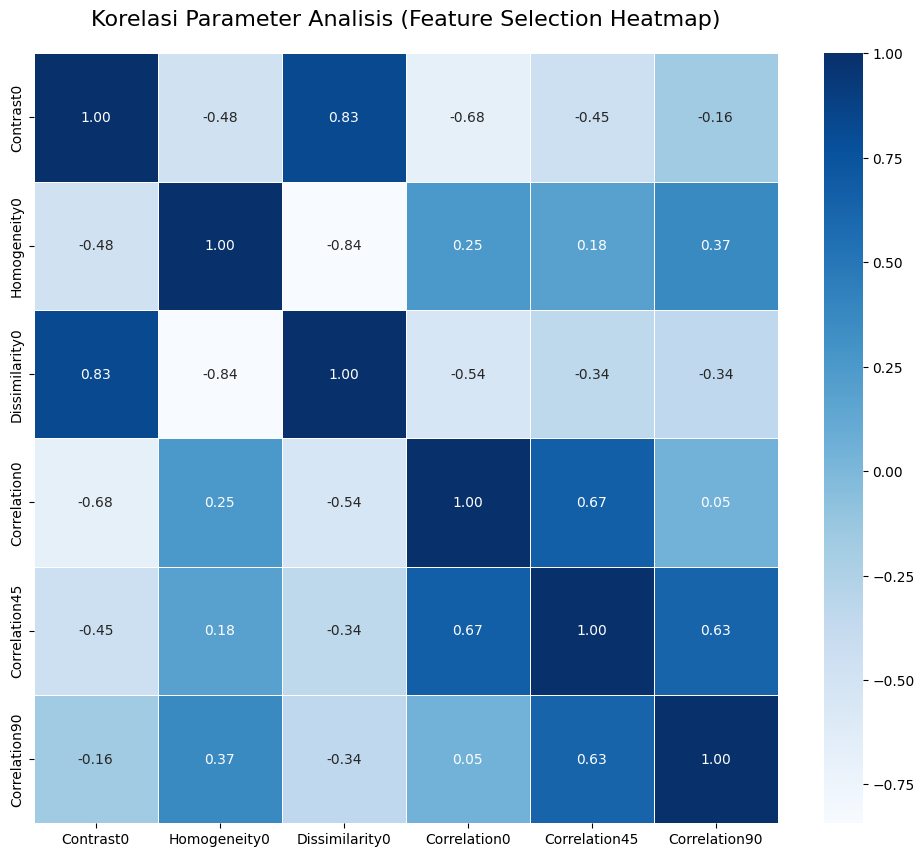

In [16]:
corr_matrix = df.drop(columns=['Label','Filename']).corr()
threshold = 0.95
columns_to_keep = np.full((corr_matrix.shape[0],), True, dtype=bool)

for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns_to_keep[j]:
                columns_to_keep[j] = False

selected_columns = df.drop(columns=['Label','Filename']).columns[columns_to_keep]
X_selected = df[selected_columns]
y = df['Label']

print(f"Dimensi fitur inisial (Pre-selection) : 28")
print(f"Dimensi fitur akhir (Post-selection) : {len(selected_columns)}")
print(f"Kumpulan variabel fitur fungsional terpilih: {list(selected_columns)}")

plt.figure(figsize=(12, 10))
sns.heatmap(X_selected.corr(), annot=True, cmap='Blues', fmt=".2f", linewidths=.5)
plt.title('Korelasi Parameter Analisis (Feature Selection Heatmap)', fontsize=16, pad=20)
plt.show()

## 17. Data Splitting (Train & Test)

Menyetarakan persaingan obyektivitas, model kecerdasan buatan dilarang mengintip atau diuji memakai tumpukan memori soal yang pernah dilatih kepadanya.

Mekanisme partisi matriks acak (*random*) `train_test_split` beroperasi menyabet dataset utuh kita dengan pembelahan rasio 80:20. Fraksi terbesar dikhususkan penuh pada *Data Latih*, dan 20% dikerangkeng jadi *Data Uji*. Peninjauan presisi matriks pembelahan di baris cetak bawah mengamankan persentase pembagian data ini.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
print(f"Distribusi dimensi Data Latih (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Distribusi dimensi Data Uji (X_test, y_test): {X_test.shape}, {y_test.shape}")

Distribusi dimensi Data Latih (X_train, y_train): (160, 6), (160,)
Distribusi dimensi Data Uji (X_test, y_test): (40, 6), (40,)


## 18. Feature Normalization (Z-Score)

Membaca interval angka jarak (*distance calculation*) mutlak dalam pengoperasian metode semacam KNN dan pemisah fungsi linear kuadratik di SVM mengharuskan data diseragamkan terlebih dahulu jangkauan rasio nominalnya (*Feature Normalization*).

Rentang perbedaan curam antar nilai diperas oleh rumus *Z-Score*, di mana grafik digeser ke simetri ekuilibrium skala rata-rata di titik (0) dan menyebar wajar di standard deviasi (1). Pembocoran referensi statistik dihalau dengan cara menghitung rata-rata penyetaraan cuma dari himpunan Data Latih belaka. Output sampel tabel ini mempamerkan betapa cantiknya perataan skor numerik kita kini.

In [18]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_train = (X_train - mean_train) / std_train
X_test  = (X_test  - mean_train) / std_train

print("Verifikasi hasil distribusi Z-Score Normalization (Train Data):")
display(X_train.head())

Verifikasi hasil distribusi Z-Score Normalization (Train Data):


,Contrast0,Homogeneity0,Dissimilarity0,Correlation0,Correlation45,Correlation90
79,-0.406998,0.799057,-0.774662,-0.369678,-0.448749,0.052262
197,-0.201547,0.772918,-0.484332,-0.782360,-1.547470,-0.667283
38,-0.255863,-0.032931,-0.318394,0.284995,1.020960,1.150628
24,1.069523,0.106232,0.747369,0.330579,0.010966,-0.675548
122,-1.134902,-0.059435,-0.456213,1.490370,-0.576177,-1.772687


## 19. Inisialisasi Model Klasifikasi

In [19]:
def generateClassificationReport(y_true, y_pred, model_name):
    print(f"=== Laporan Metrik Evaluasi: {model_name} ===")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel('Predictive Class')
    plt.ylabel('Actual Class')
    plt.show()
    
    print(f"Accuracy Score: {accuracy_score(y_true, y_pred) * 100:.2f}%\n")

rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Tiba saatnya peluit kompetisi ditiup. Sebagai landasan pijak evaluasi metrik pelaporan kompetisi ini, algoritma terpusat `generateClassificationReport` diprogram untuk mempresentasikan otomatis rapor ketajaman skor, bersanding grafik diagnosis kotak hijau memukau *Confusion Matrix*.

Membawa spesifikasi ekstraksi berpenambahan parameter fungsi ujung/deteksi tepi kali ini (*pre 2*), tiga maestro analisis diandalkan kembali ke gelanggang pertarungan:
1. **Random Forest (rf)**: Arsitektur pohon deterministik kombinasi penyaring putusan klasifikasi hierarkis.
2. **Support Vector Machine (svm)**: Berbekal tameng kernel analitik fungsi (*RBF*), membelah zona tebakan di balik garis perbatasan geometris semu.
3. **K-Nearest Neighbors (knn)**: Pembanding kedekatan klasifikasi metrik observasional berbasis jarak korelasi antar titik uji terdekat.

## 20. Evaluasi Model Random Forest

Gelanggang uji awal diterjang arsitektur probabilitas klasifikasi himpunan deterministik, algoritma *Random Forest*. Seusai dijejali memori dari Data Latih lewat metode `.fit()`, fungsi kecerdasan buatan pelacak pola tepi bercak daun ini dihadapkan menginvasi matriks *test set* independen.

Perhatikan! Jika di `pre 1` kita sempat melihat rekor kehandalan Random Forest mencapai akurasi hingga 97.5%, laporan komparatif presisi di bawah layar justru mengonfirmasi skor yang meredup menjadi sekitar **80.0%**. Tambahan beban ekstraksi detail ujung siluet nampaknya menciptakan tumpukan distraksi informasi sehingga model tersandung di beberapa selisih tebakan negatif dari paparan matriks evaluasi *Confusion Matrix*-nya.

=== Laporan Metrik Evaluasi: Random Forest ===
Classification Report:
                     precision    recall  f1-score   support

Grape_black_rot_100       0.74      0.89      0.81        19
     daun_sehat_100       0.88      0.71      0.79        21

           accuracy                           0.80        40
          macro avg       0.81      0.80      0.80        40
       weighted avg       0.81      0.80      0.80        40



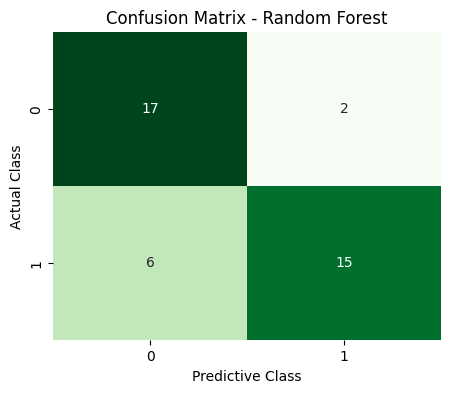

Accuracy Score: 80.00%



In [20]:
rf.fit(X_train, y_train)

prediksi_rf = rf.predict(X_test)
generateClassificationReport(y_test, prediksi_rf, "Random Forest")

## 21. Evaluasi Model Support Vector Machine

Pengecekan stabilitas model selanjutnya diampu oleh kepiawaian kerangka analitik *Support Vector Machine* (SVM). Modul ekstrapolasi matriks dengan bantuan kernel lentur (*RBF*) ini semestinya tangguh dalam menarik korelasi partisi linearitas tekstur daun.

Nyatanya, rentang angka *Classification Report* terlampir di bawah mencetak kemerosotan rasio evaluasi ke takaran akurasi stabil sebesar **87.5%**. Angka absolut 100% dari tahap `pre 1` kandas di sini karena kemunculan garis-garis patah dari *edge detection* sepertinya menumpulkan kepekaan SVM dalam merampungkan tarikan wilayah tebakannya.

=== Laporan Metrik Evaluasi: Support Vector Machine ===
Classification Report:
                     precision    recall  f1-score   support

Grape_black_rot_100       0.82      0.95      0.88        19
     daun_sehat_100       0.94      0.81      0.87        21

           accuracy                           0.88        40
          macro avg       0.88      0.88      0.87        40
       weighted avg       0.88      0.88      0.87        40



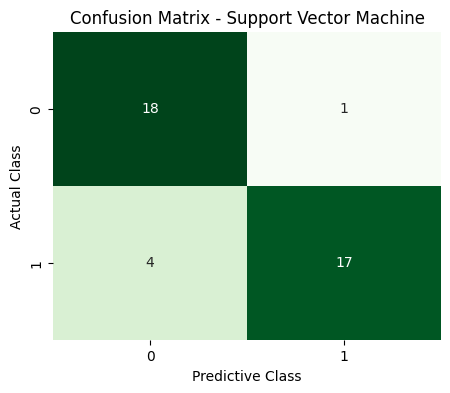

Accuracy Score: 87.50%



In [21]:
svm.fit(X_train, y_train)

prediksi_svm = svm.predict(X_test)
generateClassificationReport(y_test, prediksi_svm, "Support Vector Machine")

## 22. Evaluasi Model K-Nearest Neighbors

Sesi evaluasi pamungkas komparasi dibebankan kepada validasi metrik K-Nearest Neighbors (KNN). Algoritma parametrik berbasis rentang irisan kedekatan *test data* ini mengkalkulasi jangkauan sebaran siluet tekstur di kerangka acuan fitur terpusat (*Z-Score*).

Sama seperti fenomena di kedua panggung sebelumnya, rentetan kalkulasi ketepatan tebakan meleset cukup signifikan dan kembali bertahan menjejak tanah persentase **85.0%**. Fenomena melesetnya tebakan blok matriks di persentase ini memperkuat dugaan bahwa metode *preprocessing* dengan penegasan fungsi deteksi tepi semacam Sobel dan Roberts acap kali memunculkan efek tebaran gradasi garis (*noise* mikro) yang rupanya membiaskan ketajaman tiga model andalan kita.

=== Laporan Metrik Evaluasi: K-Nearest Neighbors ===
Classification Report:
                     precision    recall  f1-score   support

Grape_black_rot_100       0.84      0.84      0.84        19
     daun_sehat_100       0.86      0.86      0.86        21

           accuracy                           0.85        40
          macro avg       0.85      0.85      0.85        40
       weighted avg       0.85      0.85      0.85        40



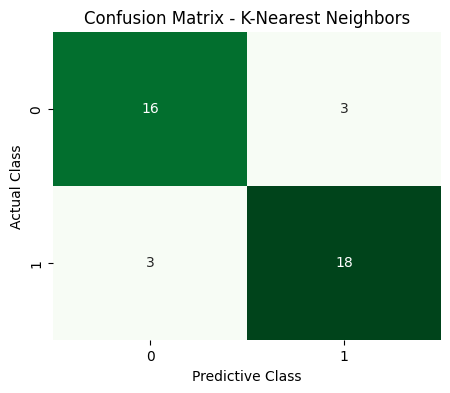

Accuracy Score: 85.00%



In [22]:
knn.fit(X_train, y_train)

prediksi_knn = knn.predict(X_test)
generateClassificationReport(y_test, prediksi_knn, "K-Nearest Neighbors")